# Analyse exploratoire


Les valeurs manquantes sont fréquentes dans les données réelles et peuvent fortement impacter les analyses. Il est donc nécessaire de choisir des méthodes adaptées pour les traiter.

L’objectif de ce projet est de comparer différentes méthodes d’imputation et d’identifier dans quels cas elles sont pertinentes.

In [1]:
# Importation des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression

# Initialissation (pour reproductibilité)
np.random.seed(42)

Detection des valeurs manquantes :

Dans cette première étape :

Nous préparons le jeu de données afin de disposer d’une base fiable pour l’analyse. Le dataset est d’abord chargé en prenant en compte le symbole “?”, qui est interprété comme valeur manquante. Une analyse est ensuite réalisée pour identifier et quantifier ces valeurs manquantes dans chaque variable, ce qui permet de mieux comprendre leur répartition dans le jeu de données.

Afin de garantir la qualité des données, les colonnes contenant un trop grand nombre de valeurs manquantes (plus de 75 %) sont supprimées, car elles ne contiennent pas suffisamment d’information exploitable. À partir de ce jeu de données nettoyé, un dataset de référence, noté df_ref, est ensuite construit en supprimant les lignes contenant encore des valeurs manquantes.

Ce dataset de référence joue un rôle central dans notre étude : il constitue une version complète des données, sans valeurs manquantes, que l’on considère comme la “vérité”. Il permet de simuler artificiellement des valeurs manquantes par la suite, tout en conservant les valeurs réelles pour pouvoir comparer les résultats des différentes méthodes d’imputation. Cela rend possible une évaluation objective des performances des méthodes, en mesurant leur capacité à reconstruire les valeurs initiales.



In [2]:
# =========================================================
# 1. Préparation des données
# =========================================================

    # 1.1 Chargement du dataset

# Les "?" sont considérés comme des valeurs manquantes
df = pd.read_csv("diabetic_data.csv", na_values=["?"])

print("Shape initiale :", df.shape)


    # 1.2 Détection des valeurs manquantes

missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    "nb_valeurs_manquantes": missing_count,
    "pourcentage": missing_percent
})

# On garde seulement les colonnes qui ont des valeurs manquantes
missing_table = missing_table[missing_table["nb_valeurs_manquantes"] > 0]
missing_table = missing_table.sort_values(by="pourcentage", ascending=False)

print("\nColonnes avec valeurs manquantes :")
print(missing_table)


    # 1.3 Suppression des colonnes trop vides

threshold = 75  # seuil en %

cols_to_drop = missing_percent[missing_percent > threshold].index

print("\nColonnes supprimées :")
print(cols_to_drop)

df_clean = df.drop(columns=cols_to_drop)

print("\nShape après suppression des colonnes trop vides :", df_clean.shape)
print("Valeurs manquantes restantes dans df_clean :", df_clean.isnull().sum().sum())


    # 1.4 Création du dataset de référence (df_ref)

df_ref = df_clean.dropna().copy()

print("\nShape de df_ref :", df_ref.shape)
print("Pourcentage conservé :", len(df_ref) / len(df))
print("Valeurs manquantes restantes dans df_ref :", df_ref.isnull().sum().sum())

/tmp/ipykernel_1090/1075551419.py:8: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("diabetic_data.csv", na_values=["?"])


Shape initiale : (101766, 50)

Colonnes avec valeurs manquantes :
                   nb_valeurs_manquantes  pourcentage
weight                             98569    96.858479
max_glu_serum                      96420    94.746772
A1Cresult                          84748    83.277322
medical_specialty                  49949    49.082208
payer_code                         40256    39.557416
race                                2273     2.233555
diag_3                              1423     1.398306
diag_2                               358     0.351787
diag_1                                21     0.020636

Colonnes supprimées :
Index(['weight', 'max_glu_serum', 'A1Cresult'], dtype='object')

Shape après suppression des colonnes trop vides : (101766, 47)
Valeurs manquantes restantes dans df_clean : 94280

Shape de df_ref : (26755, 47)
Pourcentage conservé : 0.26290706129748637
Valeurs manquantes restantes dans df_ref : 0


Dans cette étape, nous analysons le dataset de référence (df_ref) afin de mieux comprendre les caractéristiques des données avant d’introduire artificiellement des valeurs manquantes. Cette analyse permet d’orienter le choix des méthodes d’imputation en fonction de la structure des données.


=== Test de normalité (Shapiro) ===
time_in_hospital : p-value = 0.00000
num_lab_procedures : p-value = 0.00001
num_medications : p-value = 0.00000
number_diagnoses : p-value = 0.00000

=== Corrélation (df_ref) ===
                    time_in_hospital  num_lab_procedures  num_medications  \
time_in_hospital            1.000000            0.295395         0.456300   
num_lab_procedures          0.295395            1.000000         0.265501   
num_medications             0.456300            0.265501         1.000000   
number_diagnoses            0.228072            0.139283         0.249727   

                    number_diagnoses  
time_in_hospital            0.228072  
num_lab_procedures          0.139283  
num_medications             0.249727  
number_diagnoses            1.000000  


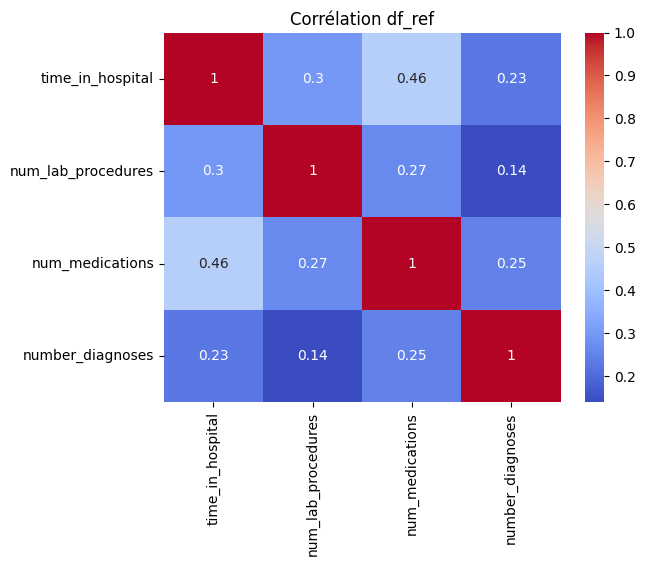

In [3]:
# =========================================================
# 2. ANALYSE DES DONNEES INITIALES (df_ref)
# =========================================================

cols_analysis = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications",
    "number_diagnoses"
]

print("\n=== Test de normalité (Shapiro) ===")

for col in cols_analysis:
    stat, p = shapiro(df_ref[col].sample(500))
    print(f"{col} : p-value = {p:.5f}")

# Corrélation initiale
print("\n=== Corrélation (df_ref) ===")
print(df_ref[cols_analysis].corr())

sns.heatmap(df_ref[cols_analysis].corr(), annot=True, cmap="coolwarm")
plt.title("Corrélation df_ref")
plt.show()

Les tests de normalité :

Montrent que les variables ne suivent pas une distribution normale (p-value < 0.05). Cela justifie l’utilisation de la médiane plutôt que de la moyenne, cette dernière étant sensible aux distributions asymétriques et aux valeurs extrêmes.

L’analyse des corrélations :

Met en évidence des relations modérées entre les variables, notamment entre la durée d’hospitalisation et le nombre de médicaments. Cela indique que certaines variables sont dépendantes les unes des autres.

Les corrélations entre les variables, bien que modérées, permettent d’expliquer les bonnes performances de la régression, qui exploite ces relations. En revanche, leur intensité limitée explique pourquoi KNN, basé sur la similarité globale, reste moins performant.



Création du jeux de données avec valeurs manquantes (MCAR) :    

Afin de comparer les méthodes, nous créons artificiellement des valeurs manquantes (MCAR) sur un dataset propre, ce qui permet de comparer les valeurs imputées aux vraies valeurs.

In [4]:

# =========================================================
# 2. Création du dataset dégradé (MCAR)
# =========================================================

    # 2.1 Sélection des variables pertinentes
num_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

print("Colonnes utilisées pour l'imputation :")
print(num_cols)

df_mcar = df_ref.copy() # Création d'une copie


    # 2.2 Création du dataset dégradé (MCAR)

missing_rate = 0.1  # 10%

for col in num_cols:
    mask = np.random.rand(len(df_mcar)) < missing_rate
    df_mcar.loc[mask, col] = np.nan


    # 2.3 Vérification des valeurs manquantes

print("\nNombre de NA par colonne :")
print(df_mcar[num_cols].isnull().sum())

print("\nPourcentage de NA par colonne :")
print(df_mcar[num_cols].isnull().mean())

Colonnes utilisées pour l'imputation :
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Nombre de NA par colonne :
time_in_hospital      2644
num_lab_procedures    2692
num_procedures        2655
num_medications       2659
number_outpatient     2790
number_emergency      2734
number_inpatient      2596
number_diagnoses      2751
dtype: int64

Pourcentage de NA par colonne :
time_in_hospital      0.098823
num_lab_procedures    0.100617
num_procedures        0.099234
num_medications       0.099383
number_outpatient     0.104280
number_emergency      0.102187
number_inpatient      0.097029
number_diagnoses      0.102822
dtype: float64


Le choix des méthodes d’imputation a  été fait en fonction des caractéristiques du jeu de données. Nous avons retenu trois méthodes principales : la médiane, KNN et la régression. La médiane est adaptée car les distributions observées sont souvent asymétriques et contiennent des valeurs extrêmes. La méthode KNN a été choisie car les variables sont numériques et comparables entre elles, ce qui permet d’exploiter la similarité entre observations. Enfin, la régression est particulièrement adaptée dans notre cas, car l’analyse multivariée a mis en évidence des relations entre les variables, que ce type de méthode permet d’exploiter efficacement.

À l’inverse, certaines méthodes n’ont pas été retenues. L’imputation par la moyenne en raison de la présence d’outliers, qui peuvent fortement biaiser les résultats. La suppression des lignes contenant des valeurs manquantes n’est pas pertinente ici, car elle entraînerait une perte importante d’information. Le mode est principalement adapté aux variables catégorielles, ce qui n’est pas le cas des variables étudiées. Concernant le hot-deck, elle est particulièrement adaptée lorsque des groupes homogènes sont clairement identifiables dans les données. Dans notre cas, l’absence de segmentation nette entre les individus rend moins pertinante cette approche.

Enfin, l’imputation multiple à une  approche qui est surtout pertinente dans une logique d’inférence statistique. Notre étude est principalement comparative. L’imputation multiple aurait donc complexifié l’analyse sans apporter de gain direct pour la comparaison des méthodes dans ce cadre.



1. Imputation par la mediane

In [5]:
# =========================================================
# 3. Méthodes d’imputation
# =========================================================

    # 3.1 Imputation par la médiane

median_imputer = SimpleImputer(strategy="median")

df_median = df_mcar.copy()
df_median[num_cols] = median_imputer.fit_transform(df_mcar[num_cols])

print("NA après médiane :", df_median[num_cols].isnull().sum().sum())

NA après médiane : 0


2. Imputation par KNN

In [6]:
  # 3.2 Imputation par KNN

knn_imputer = KNNImputer(n_neighbors=5)

df_knn = df_mcar.copy()
df_knn[num_cols] = knn_imputer.fit_transform(df_mcar[num_cols])

print("NA après KNN :", df_knn[num_cols].isnull().sum().sum())

NA après KNN : 0


3. Imputation par régression

In [7]:
# 3.3 Imputation par régression

df_reg = df_mcar.copy()

for col in num_cols:
    # lignes avec valeur manquante
    missing = df_reg[col].isnull()

    if missing.sum() == 0:
        continue

    # données d'entraînement (sans NA)
    train = df_reg[~missing]
    test = df_reg[missing]

    X_train = train[num_cols].drop(columns=[col])
    y_train = train[col]

    X_test = test[num_cols].drop(columns=[col])

    # supprimer lignes avec NA dans X_train
    valid = X_train.notnull().all(axis=1)
    X_train = X_train[valid]
    y_train = y_train[valid]

    # supprimer NA dans X_test
    X_test = X_test.fillna(X_train.mean())

    #model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # prédiction
    df_reg.loc[missing, col] = model.predict(X_test)

    # correction valeurs négatives
    df_reg[col] = df_reg[col].clip(lower=0)

print("NA après régression :", df_reg[num_cols].isnull().sum().sum())

NA après régression : 0


 on à plusieurs jeux de données :     

* df_ref → vérité
* df_mcar → données cassées
* df_median → imputé simple
* df_knn → imputé avancé
* df_reg → imputé prédictif

# Analyse comparaison des resultat :
 1. Comparaison des méthodes (ERREUR/ par metric)
2. Comparaison des données (IMPACT)

In [8]:
# =========================================================
# 4. Évaluation des méthodes
# =========================================================
# On compare uniquement sur les valeurs qu'on a volontairement rendues manquantes
# dans df_mcar, car ce sont les seules pour lesquelles on connaît la vraie valeur
# dans df_ref.

    # 4.1 Comparaison des erreurs (MAE, RMSE)

results = []

for col in num_cols:
    # masque : positions où on a créé artificiellement des NaN
    mask = df_mcar[col].isnull()

    # si aucune valeur manquante dans cette colonne, on passe
    if mask.sum() == 0:
        continue

    # vraies valeurs
    y_true = df_ref.loc[mask, col]

    # valeurs imputées
    y_median = df_median.loc[mask, col]
    y_knn = df_knn.loc[mask, col]
    y_reg = df_reg.loc[mask, col]

    # calcul des métriques
    mae_median = mean_absolute_error(y_true, y_median)
    rmse_median = np.sqrt(mean_squared_error(y_true, y_median))

    mae_knn = mean_absolute_error(y_true, y_knn)
    rmse_knn = np.sqrt(mean_squared_error(y_true, y_knn))

    mae_reg = mean_absolute_error(y_true, y_reg)
    rmse_reg = np.sqrt(mean_squared_error(y_true, y_reg))

    results.append({
        "colonne": col,
        "nb_valeurs_testees": mask.sum(),
        "MAE_mediane": mae_median,
        "RMSE_mediane": rmse_median,
        "MAE_KNN": mae_knn,
        "RMSE_KNN": rmse_knn,
        "MAE_regression": mae_reg,
        "RMSE_regression": rmse_reg
    })

results_df = pd.DataFrame(results)

print("===== Comparaison des méthodes par colonne =====")
print(results_df)


===== Comparaison des méthodes par colonne =====
              colonne  nb_valeurs_testees  MAE_mediane  RMSE_mediane  \
0    time_in_hospital                2644     2.225794      2.968888   
1  num_lab_procedures                2692    15.598440     19.969284   
2      num_procedures                2655     1.329567      1.863718   
3     num_medications                2659     6.247838      8.617068   
4   number_outpatient                2790     0.323297      1.192269   
5    number_emergency                2734     0.283102      1.065520   
6    number_inpatient                2596     0.682974      1.556214   
7    number_diagnoses                2751     1.624500      2.019624   

     MAE_KNN   RMSE_KNN  MAE_regression  RMSE_regression  
0   2.258548   2.956288        1.984476         2.616587  
1  16.796657  21.160417       15.228827        19.061531  
2   1.506893   1.873112        1.310081         1.686649  
3   5.886423   8.024489        5.286376         7.134328  
4   0.4

In [9]:
    # 4.2 RESUME GLOBAL DES METHODES

summary_df = pd.DataFrame({
    "Méthode": ["Médiane", "KNN", "Régression"],
    "MAE_moyen": [
        results_df["MAE_mediane"].mean(),
        results_df["MAE_KNN"].mean(),
        results_df["MAE_regression"].mean()
    ],
    "RMSE_moyen": [
        results_df["RMSE_mediane"].mean(),
        results_df["RMSE_KNN"].mean(),
        results_df["RMSE_regression"].mean()
    ]
})

print("\n===== Résumé global =====")
print(summary_df)

    # 4.3 Classement des méthodes

ranking_mae = summary_df.sort_values(by="MAE_moyen")
ranking_rmse = summary_df.sort_values(by="RMSE_moyen")

print("\n===== Classement selon MAE =====")
print(ranking_mae)

print("\n===== Classement selon RMSE =====")
print(ranking_rmse)




===== Résumé global =====
      Méthode  MAE_moyen  RMSE_moyen
0     Médiane   3.539439    4.906573
1         KNN   3.725851    4.962751
2  Régression   3.391385    4.461853

===== Classement selon MAE =====
      Méthode  MAE_moyen  RMSE_moyen
2  Régression   3.391385    4.461853
0     Médiane   3.539439    4.906573
1         KNN   3.725851    4.962751

===== Classement selon RMSE =====
      Méthode  MAE_moyen  RMSE_moyen
2  Régression   3.391385    4.461853
0     Médiane   3.539439    4.906573
1         KNN   3.725851    4.962751


In [10]:
# =========================================================
# 5. Impact des méthodes sur les données
# =========================================================

    # 5.1 Comparaison des statistiques descriptives
    #pourqoi
# outliers → impact médiane
# dispersion → impact KNN

# Ici on regarde si les méthodes déforment les données
stats_comparison = pd.DataFrame(index=num_cols)

# Moyennes
stats_comparison["moyenne_ref"] = df_ref[num_cols].mean()
stats_comparison["moyenne_mcar"] = df_mcar[num_cols].mean()
stats_comparison["moyenne_mediane"] = df_median[num_cols].mean()
stats_comparison["moyenne_knn"] = df_knn[num_cols].mean()
stats_comparison["moyenne_regression"] = df_reg[num_cols].mean()

# Variances
stats_comparison["variance_ref"] = df_ref[num_cols].var()
stats_comparison["variance_mcar"] = df_mcar[num_cols].var()
stats_comparison["variance_mediane"] = df_median[num_cols].var()
stats_comparison["variance_knn"] = df_knn[num_cols].var()
stats_comparison["variance_regression"] = df_reg[num_cols].var()

print("\n===== Comparaison des statistiques descriptives =====")
print(stats_comparison)



===== Comparaison des statistiques descriptives =====
                    moyenne_ref  moyenne_mcar  moyenne_mediane  moyenne_knn  \
time_in_hospital       4.317922      4.318651         4.287161     4.305079   
num_lab_procedures    40.756681     40.698915        40.829826    40.592144   
num_procedures         1.475575      1.469544         1.422949     1.491183   
num_medications       16.246720     16.223398        16.101813    16.164463   
number_outpatient      0.290712      0.286918         0.256999     0.277944   
number_emergency       0.311755      0.315016         0.282826     0.304018   
number_inpatient       0.670641      0.669316         0.604373     0.648761   
number_diagnoses       7.355522      7.359107         7.425005     7.341282   

                    moyenne_regression  variance_ref  variance_mcar  \
time_in_hospital              4.319391      8.701269       8.699494   
num_lab_procedures           40.703634    398.623009     398.632268   
num_procedures      

L’analyse de l’impact des méthodes d’imputation sur les données :

- Evaluer si elles modifient les caractéristiques du jeu de données
- Comparer les statistiques descriptives (moyennes/variances)  
- Identifier d’éventuelles déformations.
- Vérifier si les méthodes dégrade  la structure des données.


Pourquoi moyenne/varainces
suffisant pour déterminer l'impact sur la structure des données (déformations)
Moyenne : la position des données (centre)
Variances : si les données deviennent plus concentrées (dispersion)

In [11]:

    # 5.2 Analyse des écarts par rapport aux données réelles

# Plus l'écart est faible, mieux c'est
ecarts_stats = pd.DataFrame(index=num_cols)

ecarts_stats["ecart_moyenne_mediane"] = (
    stats_comparison["moyenne_mediane"] - stats_comparison["moyenne_ref"]
).abs()

ecarts_stats["ecart_moyenne_knn"] = (
    stats_comparison["moyenne_knn"] - stats_comparison["moyenne_ref"]
).abs()

ecarts_stats["ecart_moyenne_regression"] = (
    stats_comparison["moyenne_regression"] - stats_comparison["moyenne_ref"]
).abs()

ecarts_stats["ecart_variance_mediane"] = (
    stats_comparison["variance_mediane"] - stats_comparison["variance_ref"]
).abs()

ecarts_stats["ecart_variance_knn"] = (
    stats_comparison["variance_knn"] - stats_comparison["variance_ref"]
).abs()

ecarts_stats["ecart_variance_regression"] = (
    stats_comparison["variance_regression"] - stats_comparison["variance_ref"]
).abs()

print("\n===== Écarts absolus par rapport à df_ref =====")
print(ecarts_stats)



===== Écarts absolus par rapport à df_ref =====
                    ecart_moyenne_mediane  ecart_moyenne_knn  \
time_in_hospital                 0.030761           0.012842   
num_lab_procedures               0.073145           0.164537   
num_procedures                   0.052626           0.015608   
num_medications                  0.144907           0.082258   
number_outpatient                0.033713           0.012768   
number_emergency                 0.028929           0.007737   
number_inpatient                 0.066268           0.021880   
number_diagnoses                 0.069482           0.014240   

                    ecart_moyenne_regression  ecart_variance_mediane  \
time_in_hospital                    0.001469                0.852471   
num_lab_procedures                  0.053047               39.948112   
num_procedures                      0.008250                0.297409   
num_medications                     0.019555                7.039536   
number_outpati

In [12]:

    # 5.3 Synthèse des impacts

summary_stats = pd.DataFrame({
    "Méthode": ["Médiane", "KNN", "Régression"],
    "écart_moyenne_global": [
        ecarts_stats["ecart_moyenne_mediane"].mean(),
        ecarts_stats["ecart_moyenne_knn"].mean(),
        ecarts_stats["ecart_moyenne_regression"].mean()
    ],
    "écart_variance_global": [
        ecarts_stats["ecart_variance_mediane"].mean(),
        ecarts_stats["ecart_variance_knn"].mean(),
        ecarts_stats["ecart_variance_regression"].mean()
    ]
})

print("\n===== Résumé global sur les statistiques =====")
print(summary_stats)


===== Résumé global sur les statistiques =====
      Méthode  écart_moyenne_global  écart_variance_global
0     Médiane              0.062479               6.106412
1         KNN              0.041484               4.732869
2  Régression              0.012064               5.253511


ANALYSE UNIVARIE

creation de la fonction

In [13]:
# =========================================================
# 6. Analyse exploratoire des données
# =========================================================

    # 6.1 Analyse univariée
def analyse_univariee(df, nom_df, cols):
    print(f"\n==============================")
    print(f"Analyse univariée : {nom_df}")
    print(f"==============================\n")

    # statistiques
    stats = df[cols].describe()
    print(stats)

    for col in cols:
        print(f"\n--- Variable : {col} ---")

        mean = df[col].mean()
        median = df[col].median()
        std = df[col].std()
        skew = df[col].skew()

        print(f"Moyenne : {mean:.2f}")
        print(f"Médiane : {median:.2f}")
        print(f"Écart-type : {std:.2f}")
        print(f"Asymétrie (skewness) : {skew:.2f}")

        # ==========================
        # INTERPRÉTATION AUTOMATIQUE
        # ==========================

        # symétrie
        if abs(skew) < 0.5:
            print("→ Distribution plutôt symétrique")
        elif skew > 0:
            print("→ Distribution asymétrique à droite")
        else:
            print("→ Distribution asymétrique à gauche")

        # dispersion
        if std < mean * 0.5:
            print("→ Faible dispersion")
        else:
            print("→ Forte dispersion")

        # outliers (simple)
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        outliers = df[(df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)]

        if len(outliers) > 0:
            print(f"→ Présence d'outliers ({len(outliers)})")
        else:
            print("→ Peu ou pas d'outliers")

        # ==========================
        # GRAPHIQUES
        # ==========================

        plt.figure(figsize=(10,4))

        plt.subplot(1,2,1)
        sns.histplot(df[col], bins=20, kde=True)
        plt.title(f"Distribution de {col}")

        plt.subplot(1,2,2)
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot de {col}")

        plt.show()

Selection des dolonnes

In [14]:
cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications",
    "number_diagnoses"
]


Analyse univariée : df_ref

       time_in_hospital  num_lab_procedures  num_medications  number_diagnoses
count      19695.000000        19695.000000     19695.000000      19695.000000
mean           4.536786           45.312211        14.685809          6.738360
std            3.073068           18.456459         7.375781          1.926901
min            1.000000            1.000000         1.000000          3.000000
25%            2.000000           34.000000        10.000000          5.000000
50%            4.000000           46.000000        13.000000          7.000000
75%            6.000000           58.000000        18.000000          9.000000
max           14.000000          129.000000        70.000000          9.000000

--- Variable : time_in_hospital ---
Moyenne : 4.54
Médiane : 4.00
Écart-type : 3.07
Asymétrie (skewness) : 1.10
→ Distribution asymétrique à droite
→ Forte dispersion
→ Présence d'outliers (521)


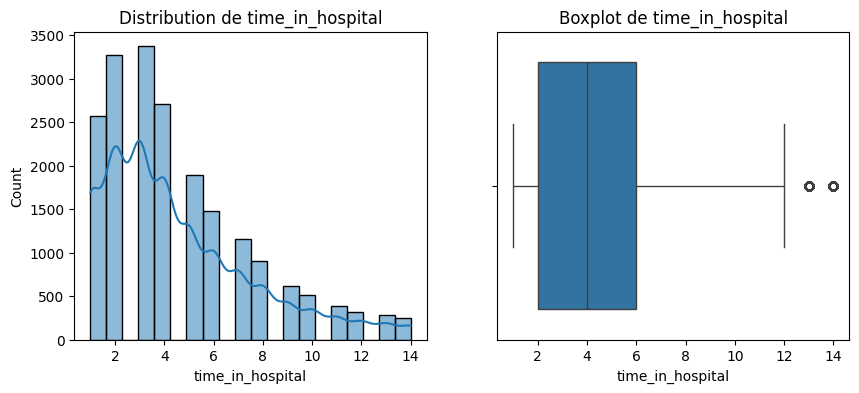


--- Variable : num_lab_procedures ---
Moyenne : 45.31
Médiane : 46.00
Écart-type : 18.46
Asymétrie (skewness) : -0.09
→ Distribution plutôt symétrique
→ Faible dispersion
→ Présence d'outliers (58)


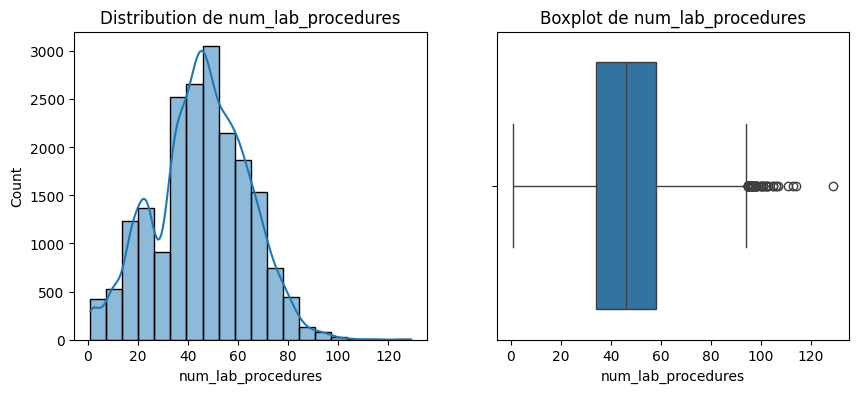


--- Variable : num_medications ---
Moyenne : 14.69
Médiane : 13.00
Écart-type : 7.38
Asymétrie (skewness) : 1.29
→ Distribution asymétrique à droite
→ Forte dispersion
→ Présence d'outliers (654)


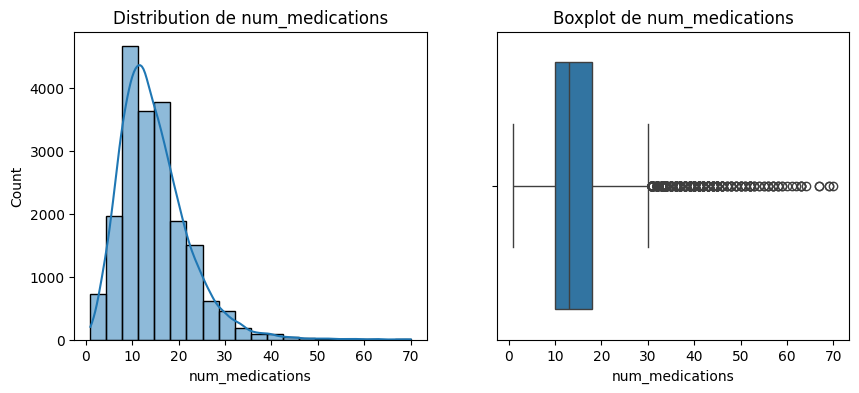


--- Variable : number_diagnoses ---
Moyenne : 6.74
Médiane : 7.00
Écart-type : 1.93
Asymétrie (skewness) : -0.26
→ Distribution plutôt symétrique
→ Faible dispersion
→ Peu ou pas d'outliers


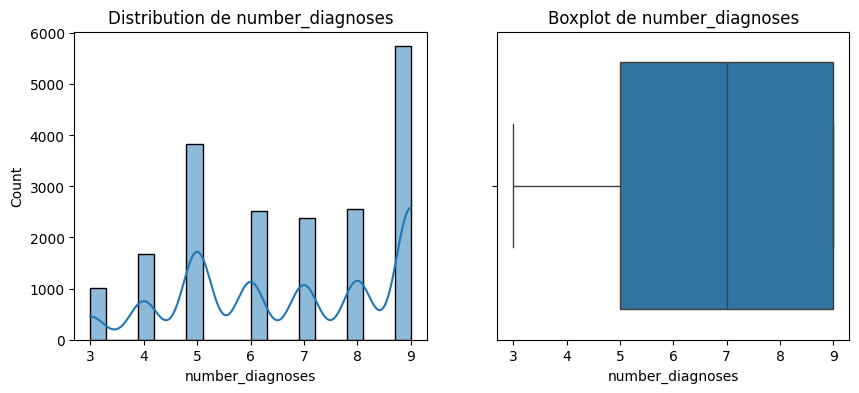

In [ ]:
#Application
analyse_univariee(df_ref, "df_ref", cols)


Analyse univariée de référence (df_ref)


Le jeu de données présente des distributions variées, avec certaines variables fortement asymétriques et contenant des valeurs extrêmes, notamment pour le nombre de médicaments. D’autres variables, comme le nombre de procédures, sont plus homogènes.



Analyse univariée : df_median

       time_in_hospital  num_lab_procedures  num_medications  number_diagnoses
count      26755.000000        26755.000000     26755.000000      26755.000000
mean           4.287161           40.829826        16.101813          7.425005
std            2.801571           18.938714         8.190335          1.805032
min            1.000000            1.000000         1.000000          3.000000
25%            2.000000           32.000000        11.000000          6.000000
50%            4.000000           42.000000        15.000000          8.000000
75%            5.000000           52.000000        20.000000          9.000000
max           14.000000          132.000000        81.000000         16.000000

--- Variable : time_in_hospital ---
Moyenne : 4.29
Médiane : 4.00
Écart-type : 2.80
Asymétrie (skewness) : 1.21
→ Distribution asymétrique à droite
→ Forte dispersion
→ Présence d'outliers (1741)


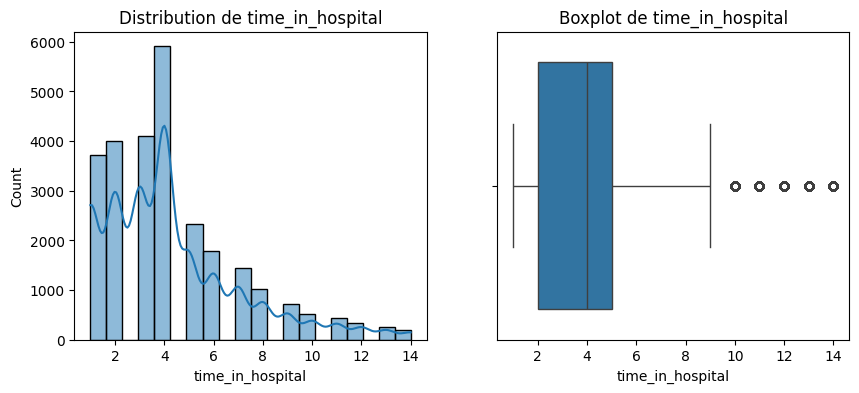


--- Variable : num_lab_procedures ---
Moyenne : 40.83
Médiane : 42.00
Écart-type : 18.94
Asymétrie (skewness) : -0.26
→ Distribution plutôt symétrique
→ Faible dispersion
→ Présence d'outliers (1568)


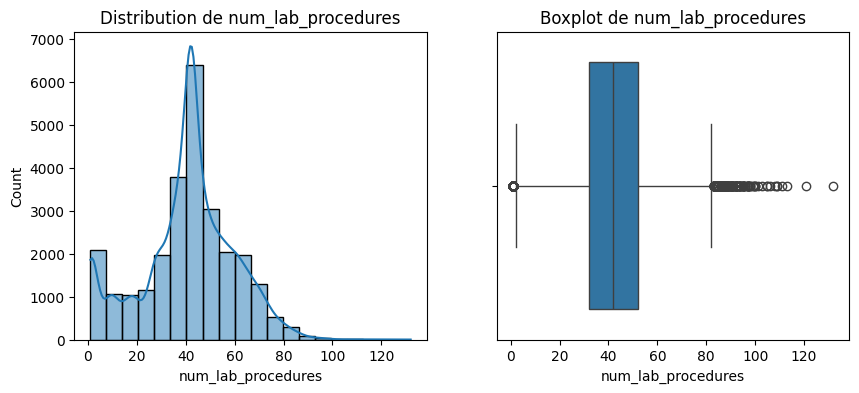


--- Variable : num_medications ---
Moyenne : 16.10
Médiane : 15.00
Écart-type : 8.19
Asymétrie (skewness) : 1.61
→ Distribution asymétrique à droite
→ Forte dispersion
→ Présence d'outliers (915)


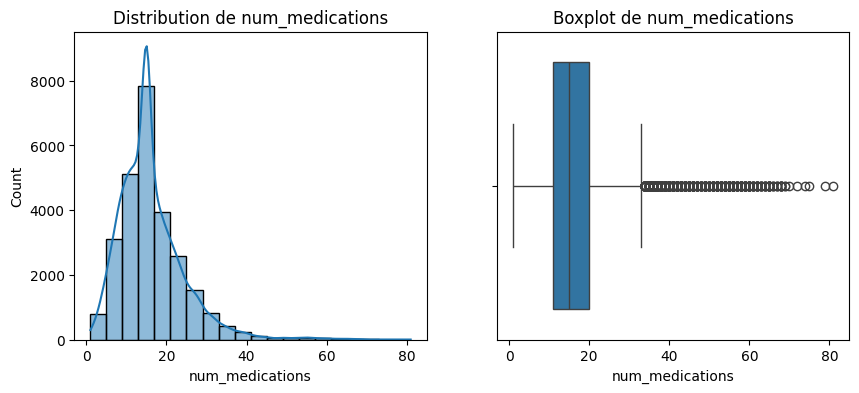


--- Variable : number_diagnoses ---
Moyenne : 7.43
Médiane : 8.00
Écart-type : 1.81
Asymétrie (skewness) : -0.75
→ Distribution asymétrique à gauche
→ Faible dispersion
→ Présence d'outliers (15)


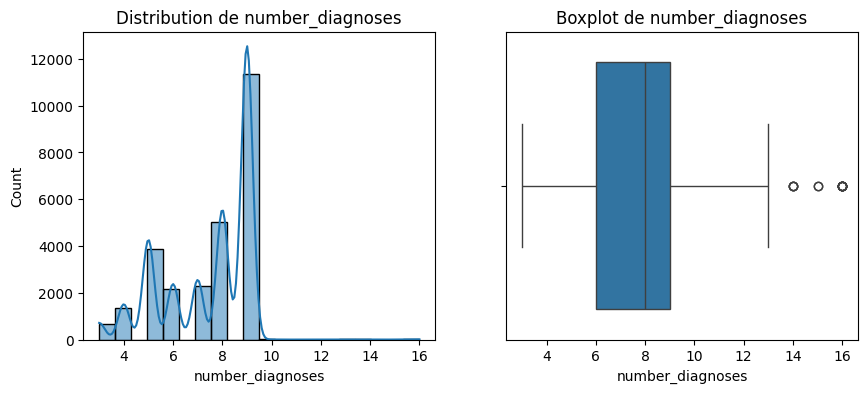

In [15]:
analyse_univariee(df_median, "df_median", cols)



Analyse univariée de mediane (df_ref)

Les moyennes proches mais une baisse des écarts-types
et explosion du nombre d’outliers.

La médiane :

- remplace par une valeur fixe
- crée des “amas artificiels”

L’imputation par la médiane modifie la distribution des données en réduisant la variabilité et en introduisant artificiellement des valeurs fréquentes, ce qui augmente le nombre d’outliers.


Analyse univariée : df_knn

       time_in_hospital  num_lab_procedures  num_medications  number_diagnoses
count      26755.000000        26755.000000     26755.000000      26755.000000
mean           4.305079           40.592144        16.164463          7.341282
std            2.831469           19.173847         8.295817          1.820319
min            1.000000            1.000000         1.000000          3.000000
25%            2.000000           30.000000        11.000000          6.000000
50%            4.000000           42.000000        15.000000          8.000000
75%            6.000000           53.000000        20.000000          9.000000
max           14.000000          132.000000        81.000000         16.000000

--- Variable : time_in_hospital ---
Moyenne : 4.31
Médiane : 4.00
Écart-type : 2.83
Asymétrie (skewness) : 1.16
→ Distribution asymétrique à droite
→ Forte dispersion
→ Présence d'outliers (461)


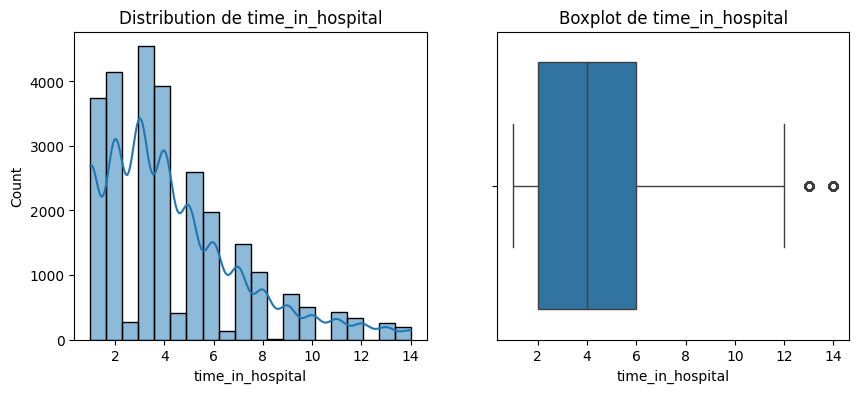


--- Variable : num_lab_procedures ---
Moyenne : 40.59
Médiane : 42.00
Écart-type : 19.17
Asymétrie (skewness) : -0.22
→ Distribution plutôt symétrique
→ Faible dispersion
→ Présence d'outliers (102)


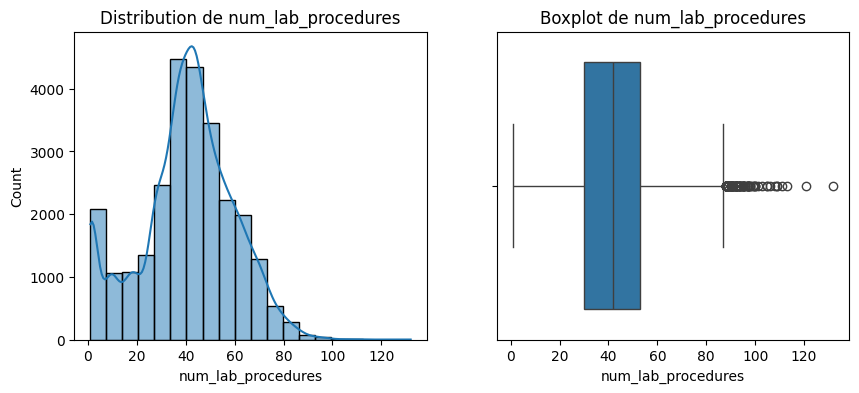


--- Variable : num_medications ---
Moyenne : 16.16
Médiane : 15.00
Écart-type : 8.30
Asymétrie (skewness) : 1.53
→ Distribution asymétrique à droite
→ Forte dispersion
→ Présence d'outliers (920)


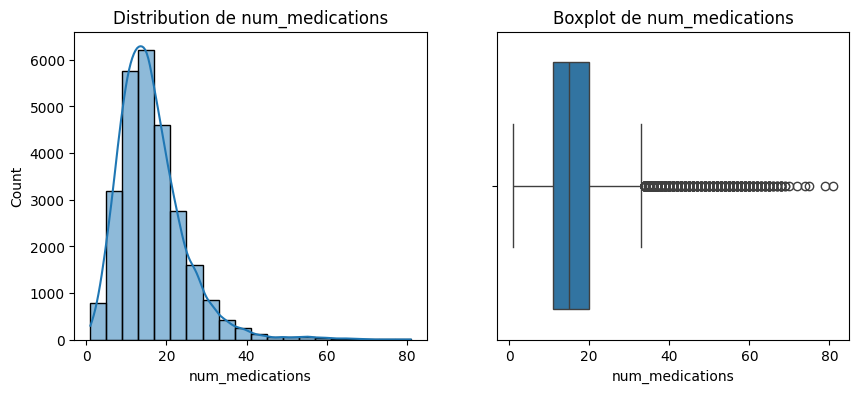


--- Variable : number_diagnoses ---
Moyenne : 7.34
Médiane : 8.00
Écart-type : 1.82
Asymétrie (skewness) : -0.61
→ Distribution asymétrique à gauche
→ Faible dispersion
→ Présence d'outliers (15)


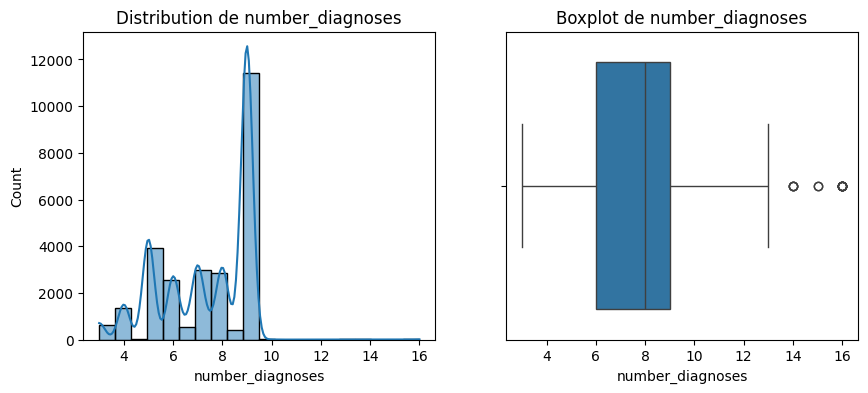

In [16]:
analyse_univariee(df_knn, "df_knn", cols)


Analyse univariée de KNN (df_knn)

Observations

Très proche de df_ref, moyennes presque identiques, variances proches, peu de distorsion
Interprétation

KNN :

-  conserve la structure
- garde la variabilité

L’imputation par KNN conserve globalement la structure des données, avec des distributions proches du jeu de référence, ce qui en fait une méthode adaptée pour préserver les caractéristiques statistiques.


Analyse univariée : df_reg

       time_in_hospital  num_lab_procedures  num_medications  number_diagnoses
count      26755.000000        26755.000000     26755.000000      26755.000000
mean           4.319391           40.703634        16.227166          7.360485
std            2.833428           19.054270         8.327088          1.805197
min            0.905499            1.000000         1.000000          3.000000
25%            2.000000           31.000000        11.000000          6.000000
50%            4.000000           42.000000        15.000000          8.000000
75%            6.000000           53.000000        20.000000          9.000000
max           14.000000          132.000000        81.000000         16.000000

--- Variable : time_in_hospital ---
Moyenne : 4.32
Médiane : 4.00
Écart-type : 2.83
Asymétrie (skewness) : 1.15
→ Distribution asymétrique à droite
→ Forte dispersion
→ Présence d'outliers (461)


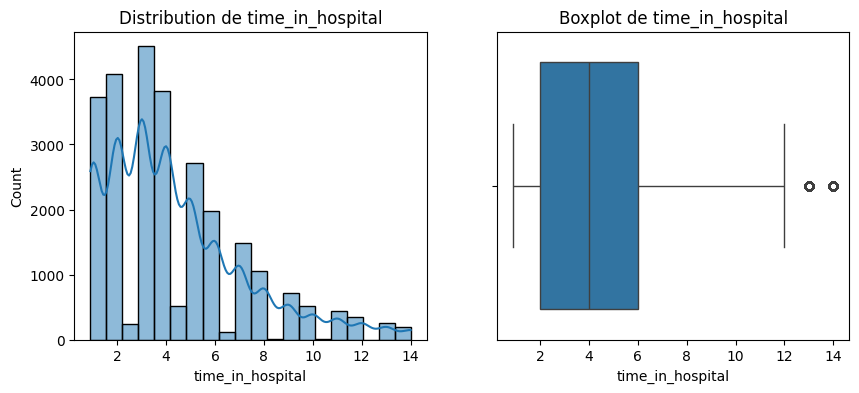


--- Variable : num_lab_procedures ---
Moyenne : 40.70
Médiane : 42.00
Écart-type : 19.05
Asymétrie (skewness) : -0.23
→ Distribution plutôt symétrique
→ Faible dispersion
→ Présence d'outliers (125)


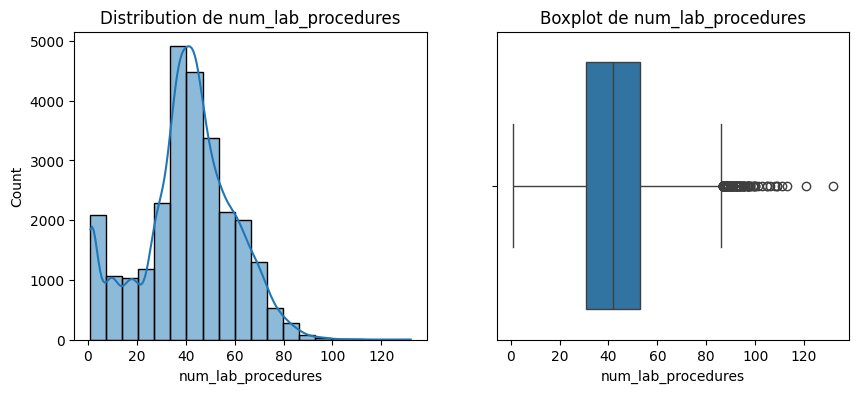


--- Variable : num_medications ---
Moyenne : 16.23
Médiane : 15.00
Écart-type : 8.33
Asymétrie (skewness) : 1.50
→ Distribution asymétrique à droite
→ Forte dispersion
→ Présence d'outliers (922)


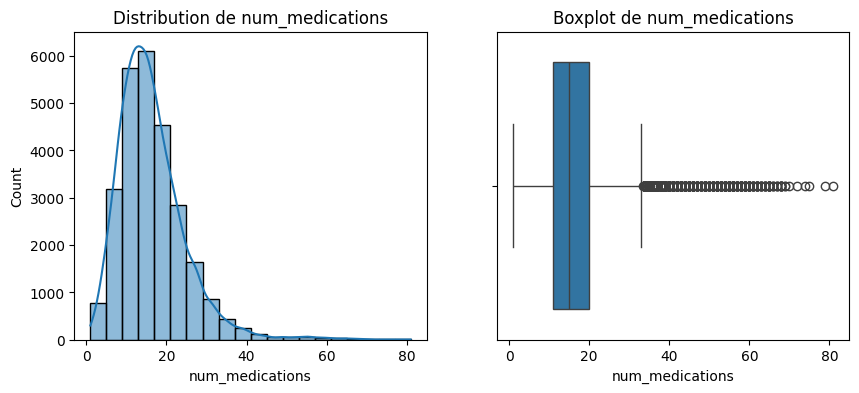


--- Variable : number_diagnoses ---
Moyenne : 7.36
Médiane : 8.00
Écart-type : 1.81
Asymétrie (skewness) : -0.64
→ Distribution asymétrique à gauche
→ Faible dispersion
→ Présence d'outliers (15)


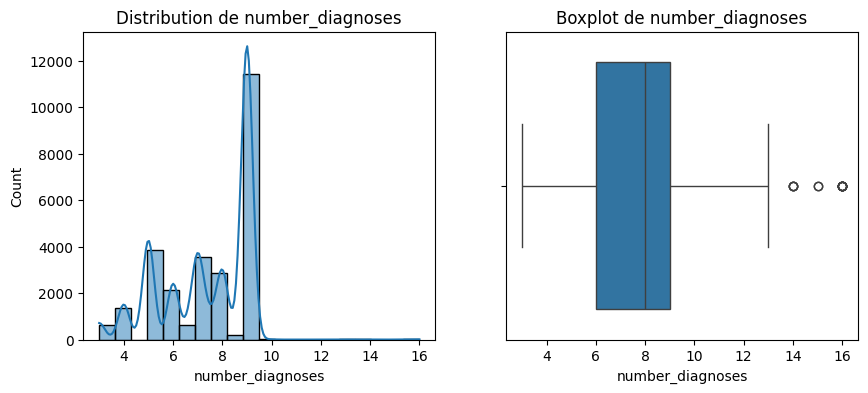

In [17]:
analyse_univariee(df_reg, "df_reg", cols)

Très proche de df_ref mais valeur négative détectée :

"min time_in_hospital = -0.24"

Interprétation

 Régression :
- très précise
- peut produire des valeurs aberrantes

L’imputation par régression permet de conserver les caractéristiques globales des données, mais peut générer des valeurs incohérentes, notamment en dehors des bornes possibles.

L’analyse univariée montre que les différentes méthodes d’imputation n’ont pas le même impact sur les distributions des variables.

L’imputation par la médiane, bien que simple, tend à réduire la variabilité des données et à introduire des concentrations artificielles de valeurs.

La méthode KNN permet de conserver des distributions proches du jeu de données initial, en respectant mieux la structure des données.

Enfin, la régression offre une très bonne approximation globale, mais peut produire des valeurs incohérentes, ce qui constitue une limite importante.

Ces résultats confirment que le choix de la méthode d’imputation doit prendre en compte à la fois la précision et l’impact sur la structure des données.

ANALYSE MULTIVARIER

In [18]:
    # 6.2 Analyse multivariée

def analyse_multivariee(df, nom_df, cols):
      print(f"\n==============================")
      print(f"Analyse multivariée : {nom_df}")
      print(f"==============================\n")

      # ==========================
      # MATRICE DE CORRÉLATION
      # ==========================
      corr = df[cols].corr()

      print("Matrice de corrélation :")
      print(corr)

      plt.figure(figsize=(6,5))
      sns.heatmap(corr, annot=True, cmap="coolwarm")
      plt.title(f"Corrélation - {nom_df}")
      plt.show()

      # ==========================
      # SCATTER PLOTS
      # ==========================
      pairs = [
          ("time_in_hospital", "num_medications"),
          ("num_lab_procedures", "num_medications"),
          ("number_diagnoses", "num_medications")
      ]

      for x, y in pairs:
          plt.figure()
          sns.scatterplot(x=df[x], y=df[y])
          plt.title(f"{x} vs {y} ({nom_df})")
          plt.show()

Application


Analyse multivariée : df_ref

Matrice de corrélation :
                    time_in_hospital  num_lab_procedures  num_medications  \
time_in_hospital            1.000000            0.295395         0.456300   
num_lab_procedures          0.295395            1.000000         0.265501   
num_medications             0.456300            0.265501         1.000000   
number_diagnoses            0.228072            0.139283         0.249727   

                    number_diagnoses  
time_in_hospital            0.228072  
num_lab_procedures          0.139283  
num_medications             0.249727  
number_diagnoses            1.000000  


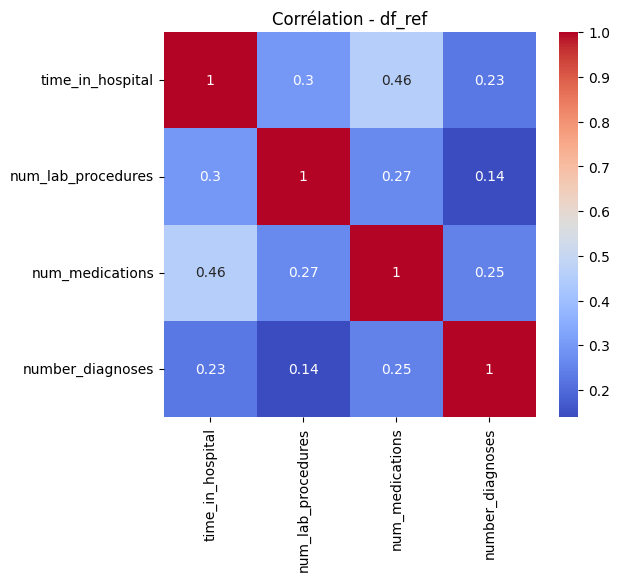

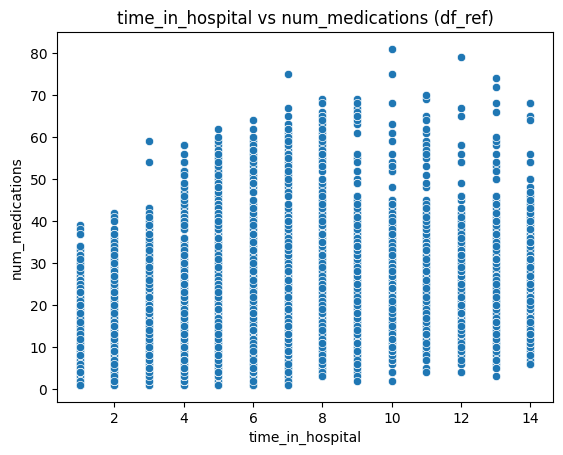

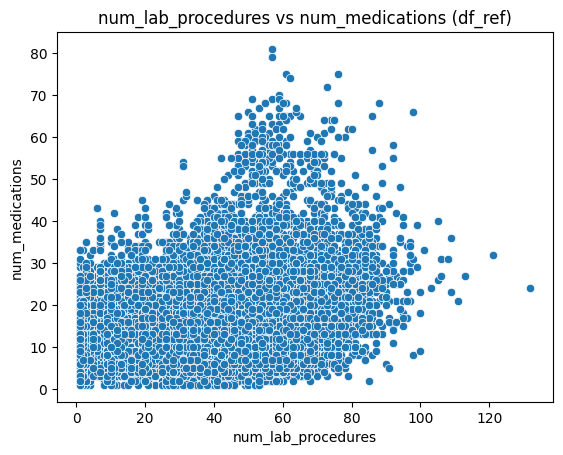

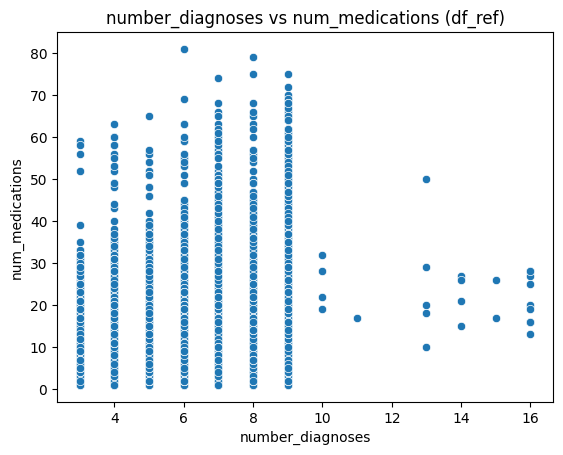


Analyse multivariée : df_median

Matrice de corrélation :
                    time_in_hospital  num_lab_procedures  num_medications  \
time_in_hospital            1.000000            0.267969         0.414485   
num_lab_procedures          0.267969            1.000000         0.243226   
num_medications             0.414485            0.243226         1.000000   
number_diagnoses            0.203356            0.125084         0.225430   

                    number_diagnoses  
time_in_hospital            0.203356  
num_lab_procedures          0.125084  
num_medications             0.225430  
number_diagnoses            1.000000  


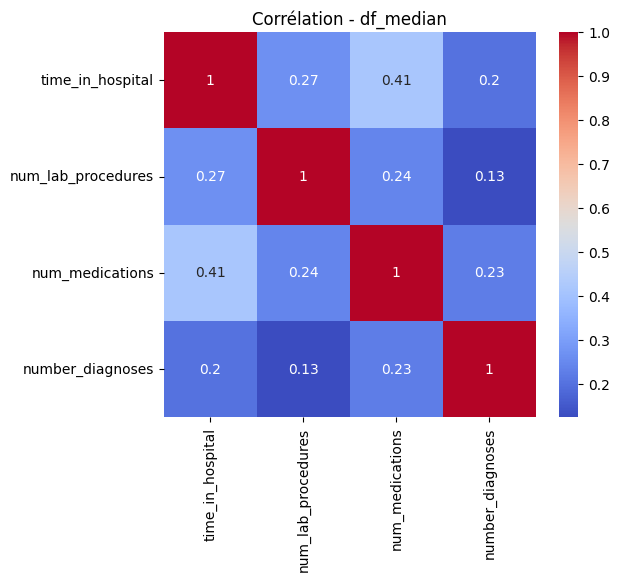

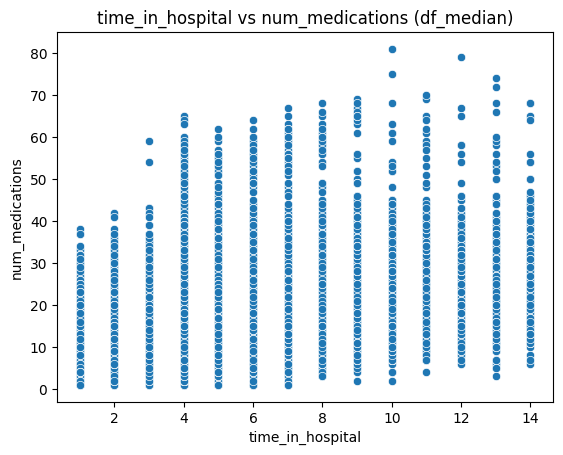

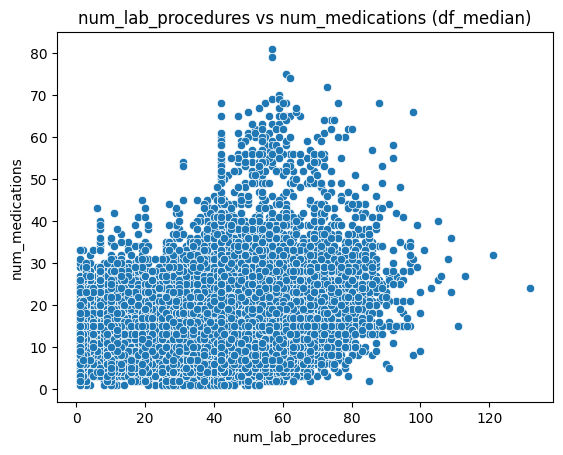

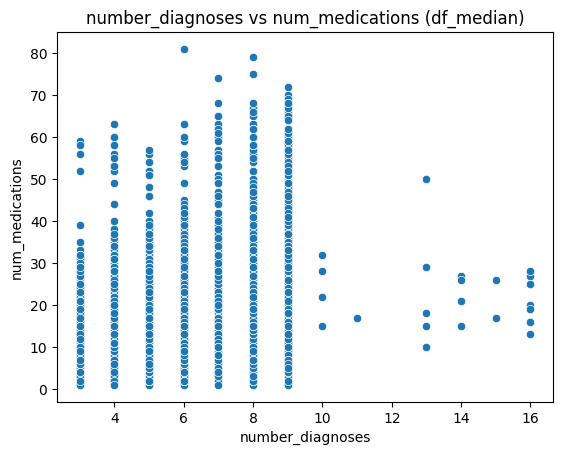


Analyse multivariée : df_knn

Matrice de corrélation :
                    time_in_hospital  num_lab_procedures  num_medications  \
time_in_hospital            1.000000            0.275228         0.438328   
num_lab_procedures          0.275228            1.000000         0.248621   
num_medications             0.438328            0.248621         1.000000   
number_diagnoses            0.229738            0.130449         0.254429   

                    number_diagnoses  
time_in_hospital            0.229738  
num_lab_procedures          0.130449  
num_medications             0.254429  
number_diagnoses            1.000000  


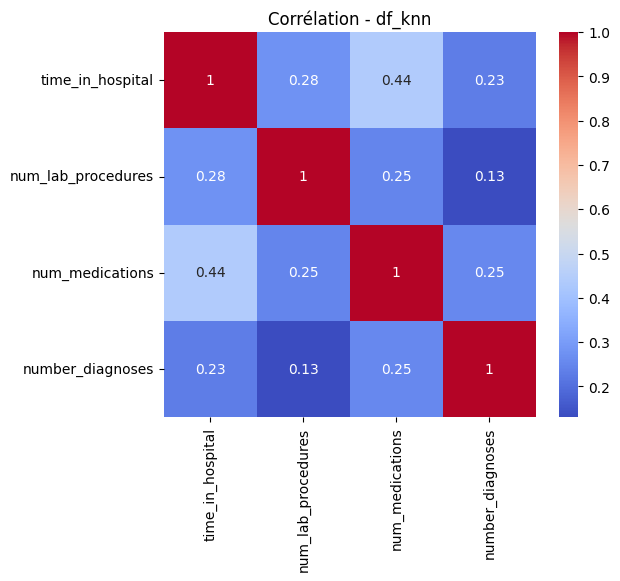

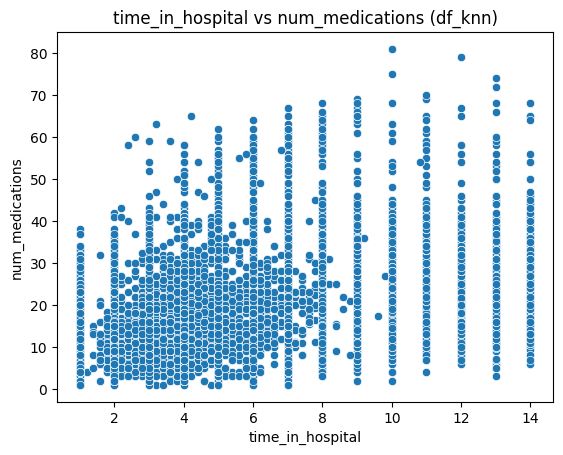

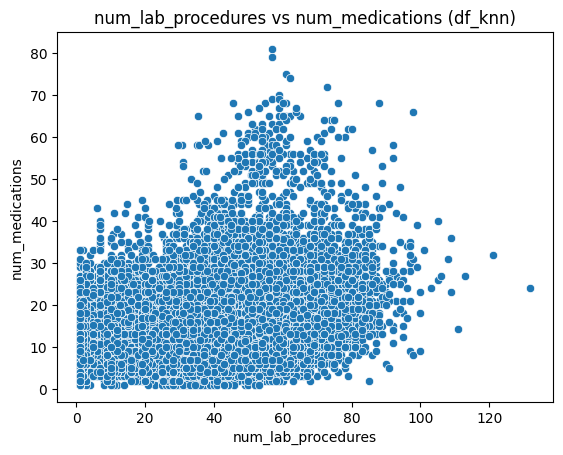

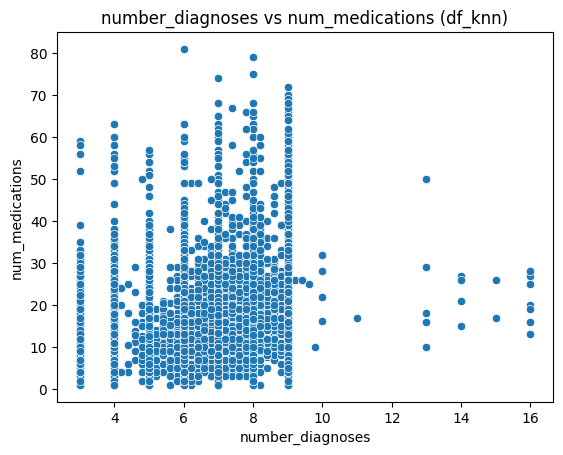


Analyse multivariée : df_reg

Matrice de corrélation :
                    time_in_hospital  num_lab_procedures  num_medications  \
time_in_hospital            1.000000            0.322046         0.491990   
num_lab_procedures          0.322046            1.000000         0.291989   
num_medications             0.491990            0.291989         1.000000   
number_diagnoses            0.247091            0.154134         0.272610   

                    number_diagnoses  
time_in_hospital            0.247091  
num_lab_procedures          0.154134  
num_medications             0.272610  
number_diagnoses            1.000000  


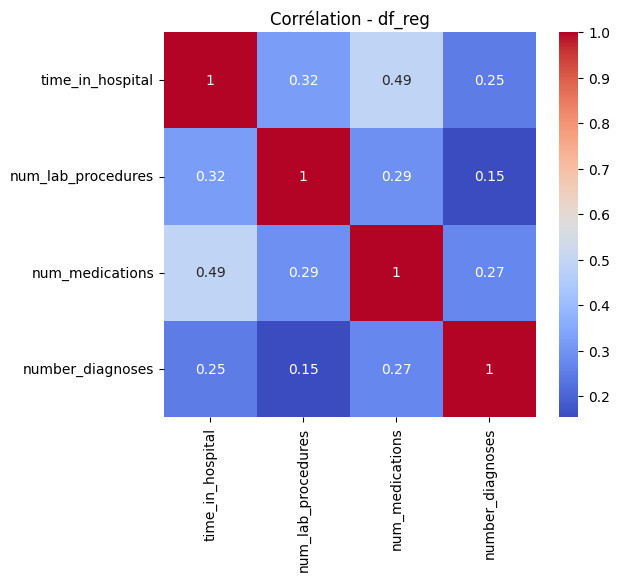

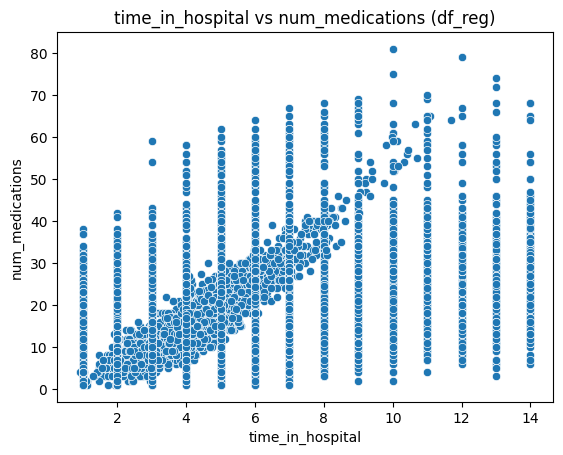

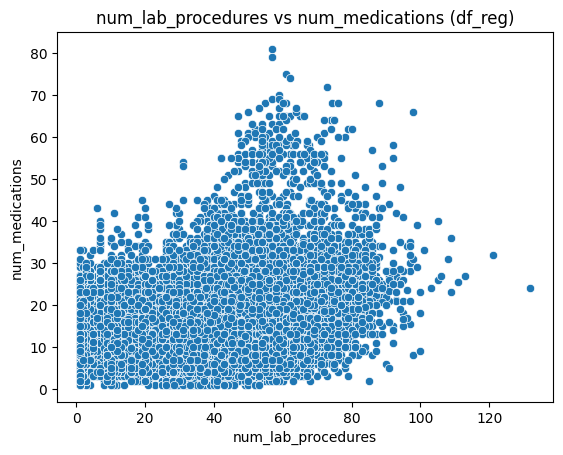

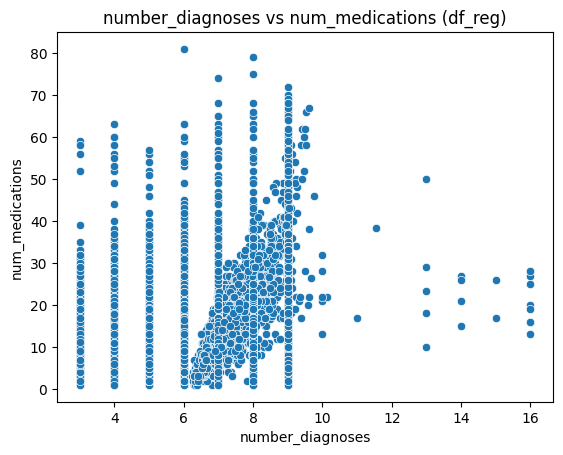

In [19]:
cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications",
    "number_diagnoses"
]

analyse_multivariee(df_ref, "df_ref", cols)
analyse_multivariee(df_median, "df_median", cols)
analyse_multivariee(df_knn, "df_knn", cols)
analyse_multivariee(df_reg, "df_reg", cols)

# Modélisation des relations entre variables


Afin d’approfondir l’analyse des relations entre les variables, un modèle de régression linéaire est appliqué sur le jeu de données de référence (df_ref). Contrairement à l’analyse de corrélation, qui permet uniquement d’identifier l’existence de relations, ce modèle permet de les quantifier et de mesurer précisément l’influence de chaque variable sur la variable cible.

Le modèle est appliqué uniquement sur df_ref, car il s’agit du seul jeu de données non modifié, représentant la structure réelle des données. L’utilisation des jeux de données imputés introduirait un biais, car ces derniers contiennent des valeurs estimées.



In [20]:
# =========================================================
# 7.  Modélisation des relations entre variablese
# =========================================================

    # 7.1 Régression linéaire
X = df_ref[[
    "time_in_hospital",
    "num_lab_procedures",
    "number_diagnoses"
]]

y = df_ref["num_medications"]

model = LinearRegression()
model.fit(X, y)

coeffs = pd.Series(model.coef_, index=X.columns)

print("\nCoefficients du modèle :")
print(coeffs)


Coefficients du modèle :
time_in_hospital      1.122445
num_lab_procedures    0.056873
number_diagnoses      0.652446
dtype: float64


Les résultats montrent que la durée d’hospitalisation (time_in_hospital) est la variable la plus influente sur le nombre de médicaments, avec un coefficient d’environ +1.12. Le nombre de diagnostics (number_diagnoses) a également un impact significatif (+0.65), tandis que le nombre de procédures de laboratoire (num_lab_procedures) a une influence plus faible. Ces résultats mettent en évidence des relations positives entre les variables.

Ces observations confirment que certaines variables sont liées entre elles de manière exploitable. Cela permet d’expliquer pourquoi les méthodes d’imputation basées sur ces relations, comme la régression, sont particulièrement performantes dans ce contexte, contrairement à des méthodes plus simples comme la médiane, qui ne prennent pas en compte ces dépendances.

INTERET DU TRAITEMENT DES VALEURS MANQUANTES

Afin de mettre en évidence l’intérêt du traitement des valeurs manquantes, une comparaison est réalisée entre le jeu de données incomplet (df_mcar) et un jeu de données après imputation (df_reg). Les résultats montrent que la présence de valeurs manquantes dégrade les analyses, notamment en réduisant le nombre d’observations exploitables et en modifiant les statistiques ainsi que les relations entre variables. À l’inverse, l’imputation permet de restaurer une structure de données plus complète et cohérente, ce qui améliore la fiabilité des analyses.

In [21]:
# =========================================================
# 9. INTERET DU TRAITEMENT DES VALEURS MANQUANTES
# =========================================================

print("\n===== COMPARAISON SANS TRAITEMENT vs AVEC IMPUTATION =====")

#  Moyennes
print("\nMoyennes df_ref :")
print(df_ref[num_cols].mean())

print("\nMoyennes df_mcar (avec NA) :")
print(df_mcar[num_cols].mean())

print("\nMoyennes df_reg (après imputation) :")
print(df_reg[num_cols].mean())


#  Corrélations
print("\nCorrélation df_ref :")
print(df_ref[num_cols].corr())

print("\nCorrélation df_mcar :")
print(df_mcar[num_cols].corr())

print("\nCorrélation df_reg :")
print(df_reg[num_cols].corr())


#  Impact sur le modèle
print("\n===== IMPACT SUR LA REGRESSION =====")

# modèle sur df_ref
X_ref = df_ref[["time_in_hospital","num_lab_procedures","number_diagnoses"]]
y_ref = df_ref["num_medications"]

model_ref = LinearRegression()
model_ref.fit(X_ref, y_ref)

print("\nCoefficients df_ref :")
print(pd.Series(model_ref.coef_, index=X_ref.columns))


# modèle sur df_mcar (drop NA)
df_mcar_drop = df_mcar.dropna()

X_mcar = df_mcar_drop[["time_in_hospital","num_lab_procedures","number_diagnoses"]]
y_mcar = df_mcar_drop["num_medications"]

model_mcar = LinearRegression()
model_mcar.fit(X_mcar, y_mcar)

print("\nCoefficients df_mcar (sans traitement) :")
print(pd.Series(model_mcar.coef_, index=X_mcar.columns))


# taille des données
print("\nNombre de lignes utilisées :")
print("df_ref :", len(df_ref))
print("df_mcar dropna :", len(df_mcar_drop))


===== COMPARAISON SANS TRAITEMENT vs AVEC IMPUTATION =====

Moyennes df_ref :
time_in_hospital       4.317922
num_lab_procedures    40.756681
num_procedures         1.475575
num_medications       16.246720
number_outpatient      0.290712
number_emergency       0.311755
number_inpatient       0.670641
number_diagnoses       7.355522
dtype: float64

Moyennes df_mcar (avec NA) :
time_in_hospital       4.318651
num_lab_procedures    40.698915
num_procedures         1.469544
num_medications       16.223398
number_outpatient      0.286918
number_emergency       0.315016
number_inpatient       0.669316
number_diagnoses       7.359107
dtype: float64

Moyennes df_reg (après imputation) :
time_in_hospital       4.319391
num_lab_procedures    40.703634
num_procedures         1.467325
num_medications       16.227166
number_outpatient      0.287485
number_emergency       0.315508
number_inpatient       0.668391
number_diagnoses       7.360485
dtype: float64

Corrélation df_ref :
                  